In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u

In [13]:
from astropy.io import fits
from astropy.table import Table

hdul = fits.open('data/dr16q_prop_May01_2024.fits')
fits_data = hdul[1].data  # Assuming the data is in the first extension    
fits_data2 = hdul[2].data  # Assuming the data is in the second extension

# Calculate apparent_mag_i from PSFFLUX (i-band is index 2)
apparent_mag_i = -2.5 * np.log10(fits_data2['PSFFLUX'][:, 2]) + 22.5

# Add apparent_mag_i as a new field to fits_data2

# Convert fits_data2 to Table, add column, convert back to FITS_rec
table_data2 = Table(fits_data2)
table_data2['apparent_mag_i'] = apparent_mag_i
fits_data2 = table_data2.as_array()

fields1 = ['RA', 'DEC', 'SDSS_NAME', 'Z_SYS', 'LOGLBOL', 'LOGLBOL_ERR', 'LOGL3000', 'LOGL3000_ERR']
fields2 = ['M_I', 'SN_MEDIAN_ALL', 'apparent_mag_i']

data = {}
for f in fields1:
    data[f] = fits_data[f]
for f in fields2:
    data[f] = fits_data2[f]

df_fits = pd.DataFrame(data)
df_fits['Z'] = df_fits['Z_SYS']

# Calculate LOGLBOL for each row in df_fits based on Z_SYS
df_fits['LOGLBOL_CALC'] = np.where(
    df_fits['Z'] < 0.7,
    np.log10(5.15) + df_fits['LOGL3000'],
    df_fits['LOGLBOL']
)
df_fits['LOGLBOL_ERR_CALC'] = np.where(
    df_fits['Z'] < 0.7,
    df_fits['LOGL3000_ERR'],
    df_fits['LOGLBOL_ERR']
)

df_fits['LOGLBOL'] = df_fits['LOGLBOL_CALC']
df_fits['LOGLBOL_ERR'] = df_fits['LOGLBOL_ERR_CALC']


/tmp/ipykernel_1203046/316102214.py:9: RuntimeWarning: divide by zero encountered in log10
  apparent_mag_i = -2.5 * np.log10(fits_data2['PSFFLUX'][:, 2]) + 22.5
/tmp/ipykernel_1203046/316102214.py:9: RuntimeWarning: invalid value encountered in log10
  apparent_mag_i = -2.5 * np.log10(fits_data2['PSFFLUX'][:, 2]) + 22.5


In [14]:
from astropy.coordinates import search_around_sky
from astropy.table import join

cat = pd.read_parquet(f"data/S82/Catalog.parquet").set_index('idx')

df_cat = cat.reset_index()[['objectId', 'RA', 'DEC']]
df_cat = df_cat.rename(columns={'RA': 'RA_w', 'DEC': 'DEC_w'})

# SkyCoord for both catalogs (assumes RA/DEC are in degrees)
coords_cat  = SkyCoord(ra=df_cat['RA_w'].values * u.deg, dec=df_cat['DEC_w'].values * u.deg)
coords_fits = SkyCoord(ra=df_fits['RA'].values    * u.deg, dec=df_fits['DEC'].values    * u.deg)

# All matches within 1 arcsec
idx_cat, idx_fits, sep2d, _ = search_around_sky(coords_cat, coords_fits, 1 * u.arcsec)

# Give df_fits a key to merge on
df_fits = df_fits.copy()
df_fits['idx'] = np.arange(len(df_fits))

# Take only the matched rows from df_cat (use iloc!), attach the matching df_fits index
df_cat_match = df_cat.iloc[idx_cat].reset_index(drop=True).copy()
df_cat_match['idx'] = idx_fits
df_cat_match['sep_arcsec'] = sep2d.to(u.arcsec).value  # handy to keep

# Inner join: repeats df_fits rows if there are multiple cat matches (expected behavior)
df_merged = pd.merge(df_fits, df_cat_match, on='idx', how='inner')

In [9]:
df = pd.read_csv('data/sample_chisqg10_ebv005sn3_fittedm2500.csv', dtype={'object_id': str})

df_merged_final = pd.merge(df, df_merged, left_on='object_id', right_on='objectId', how='inner')
df_merged_final = df_merged_final[df_merged_final['LOGLBOL'] > 43]

#df_merged_final.to_csv('data/sample_chisqg10_ebv005sn3_merged_radec.csv', index=False)

KeyError: 'LOGLBOL'

In [11]:
plt.figure(figsize=(8, 5))
mask = (df_merged_final['apparent_mag_2500'] > 0) & (df_merged_final['apparent_mag_i_rest'] < 27) & (df_merged_final['alpha_lambda'] > -10)
sc = plt.scatter(
    df_merged_final['alpha_lambda'][mask],
    df_merged_final['LOGLBOL'][mask],
    c=df_merged_final['Z'][mask],
    cmap='plasma',
    alpha=0.7
)
plt.xlabel('alpha_lambda')
plt.ylabel('LOGLBOL')
plt.title('alpha_lambda vs LOGLBOL (colored by redshift)')
plt.colorbar(sc, label='Redshift (Z)')
plt.grid(True)
plt.savefig('plots/ancillary/alpha_lambda_vs_LOGLBOL_colorZ.png', dpi=300)
plt.show()

KeyError: 'apparent_mag_i_rest'

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(df_merged_final['LOGLBOL'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('LOGLBOL')
plt.ylabel('Count')
plt.yscale('log')
plt.title('Histogram of LOGLBOL')
plt.show()

KeyError: 'LOGLBOL'

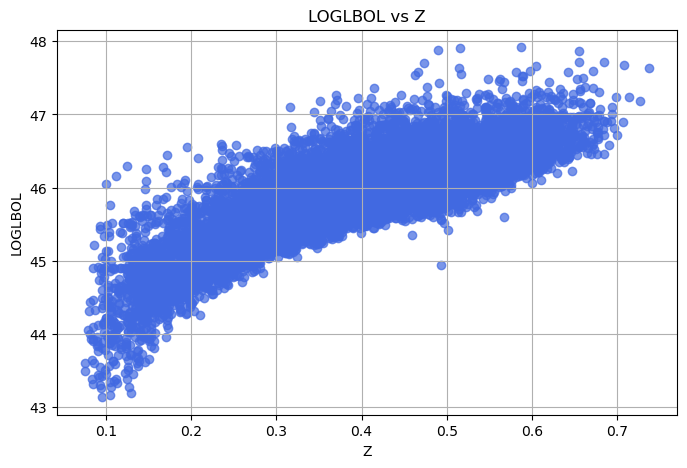

In [51]:
plt.figure(figsize=(8, 5))
plt.scatter(np.log10(1+df_merged_final['Z']), df_merged_final['LOGLBOL'], color='royalblue', alpha=0.7)
plt.xlabel('Z')
plt.ylabel('LOGLBOL')
plt.title('LOGLBOL vs Z')
plt.grid(True)
plt.show()

In [ ]:
bin_edges = np.linspace(df_merged_final['LOGLBOL'].min(), df_merged_final['LOGLBOL'].max(), 6)
print("Bin edges:", bin_edges)
df_merged_final['LOGLBOL_bin'] = pd.cut(df_merged_final['LOGLBOL'], bins=bin_edges)

for i, (bin_label, group) in enumerate(df_merged_final.groupby('LOGLBOL_bin')):
    group_shuffled = group.sample(frac=1, random_state=42).reset_index(drop=True)
    print(f"Processing bin: {i} {bin_label} with {len(group_shuffled)} entries")
    group_shuffled.to_csv(f'data/lbol_bins/sample_chisqg10_ebv005sn3_{i}.csv', index=False)


Bin edges: [43.13422365 43.6658208  44.19741795 44.7290151  45.26061225 45.79220939
 46.32380654 46.85540369 47.38700084 47.91859799]
Processing bin: 0 (43.134, 43.666] with 37 entries
Processing bin: 1 (43.666, 44.197] with 105 entries
Processing bin: 2 (44.197, 44.729] with 395 entries
Processing bin: 3 (44.729, 45.261] with 1290 entries
Processing bin: 4 (45.261, 45.792] with 3484 entries
Processing bin: 5 (45.792, 46.324] with 5044 entries
Processing bin: 6 (46.324, 46.855] with 2400 entries
Processing bin: 7 (46.855, 47.387] with 380 entries
Processing bin: 8 (47.387, 47.919] with 29 entries


/tmp/ipykernel_2986038/2773937194.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (bin_label, group) in enumerate(df_merged_final.groupby('LOGLBOL_bin')):


Reading quasars from HDF5: 100%|██████████| 20/20 [00:00<00:00, 247.58it/s]


Number of quasars loaded: 20
Number of quasars with 0 < z <= 1.0: 20
Number of quasars with z > 3: 0
Highest redshift quasar: 0.4152730338987721
Columns with NaNs: []
Skipping data cuts as apply_cut is False.
+++++ Loaded 20 entries for LOGLBOL bin 0




Reading quasars from HDF5: 100%|██████████| 100/100 [00:00<00:00, 337.80it/s]


Number of quasars loaded: 100
Populating SDSS fields...
Populating SDSS fields: 100


Populating SDSS fields: 100%|██████████| 100/100 [00:05<00:00, 17.12it/s]


...

Number of quasars loaded: 160
Number of quasars with 0 < z <= 1.0: 10
Number of quasars with z > 3: 0
Highest redshift quasar: 2.75003476809475
Columns with NaNs: ['apparent_mag_g', 'apparent_mag_g_err', 'apparent_mag_i', 'apparent_mag_i_err', 'apparent_mag_r', 'apparent_mag_r_err', 'apparent_mag_u', 'apparent_mag_u_err', 'apparent_mag_z', 'apparent_mag_z_err', 'log_amp_delta_blr_u', 'log_amp_delta_blr_u_err', 'log_jitter_u', 'log_jitter_u_err', 'log_lag_blr_u', 'log_lag_blr_u_err', 'log_sigma_band_u', 'log_sigma_band_u_err', 'log_tau_band_u_RF', 'log_tau_band_u_RF_err', 'mean_u', 'mean_u_err', 'width_blr_u', 'width_blr_u_err', 'width_cont_u', 'width_cont_u_err', 'mags_mean_u']
Skipping data cuts as apply_cut is False.
+++++ Loaded 160 entries for LOGLBOL bin 5




Reading quasars from HDF5: 100%|██████████| 160/160 [00:00<00:00, 274.36it/s]


Number of quasars loaded: 160
Number of quasars with 0 < z <= 1.0: 7
Number of quasars with z > 3: 17
Highest redshift quasar: 3.833144515205685
Columns with NaNs: ['apparent_mag_g', 'apparent_mag_g_err', 'apparent_mag_i', 'apparent_mag_i_err', 'apparent_mag_r', 'apparent_mag_r_err', 'apparent_mag_u', 'apparent_mag_u_err', 'apparent_mag_z', 'apparent_mag_z_err', 'log_amp_delta_blr_g', 'log_amp_delta_blr_g_err', 'log_jitter_g', 'log_jitter_g_err', 'log_lag_blr_g', 'log_lag_blr_g_err', 'log_sigma_band_g', 'log_sigma_band_g_err', 'log_tau_band_g_RF', 'log_tau_band_g_RF_err', 'mean_g', 'mean_g_err', 'width_blr_g', 'width_blr_g_err', 'width_cont_g', 'width_cont_g_err', 'mags_mean_g', 'log_amp_delta_blr_u', 'log_amp_delta_blr_u_err', 'log_jitter_u', 'log_jitter_u_err', 'log_lag_blr_u', 'log_lag_blr_u_err', 'log_sigma_band_u', 'log_sigma_band_u_err', 'log_tau_band_u_RF', 'log_tau_band_u_RF_err', 'mean_u', 'mean_u_err', 'width_blr_u', 'width_blr_u_err', 'width_cont_u', 'width_cont_u_err', 'mag

Reading quasars from HDF5: 100%|██████████| 160/160 [00:00<00:00, 291.26it/s]


Number of quasars loaded: 160
Number of quasars with 0 < z <= 1.0: 0
Number of quasars with z > 3: 47
Highest redshift quasar: 4.085985216215788
Columns with NaNs: ['apparent_mag_u', 'log_amp_delta_blr_g', 'log_amp_delta_blr_g_err', 'log_jitter_g', 'log_jitter_g_err', 'log_lag_blr_g', 'log_lag_blr_g_err', 'log_sigma_band_g', 'log_sigma_band_g_err', 'log_tau_band_g_RF', 'log_tau_band_g_RF_err', 'mean_g', 'mean_g_err', 'width_blr_g', 'width_blr_g_err', 'width_cont_g', 'width_cont_g_err', 'mags_mean_g', 'log_amp_delta_blr_u', 'log_amp_delta_blr_u_err', 'log_jitter_u', 'log_jitter_u_err', 'log_lag_blr_u', 'log_lag_blr_u_err', 'log_sigma_band_u', 'log_sigma_band_u_err', 'log_tau_band_u_RF', 'log_tau_band_u_RF_err', 'mean_u', 'mean_u_err', 'width_blr_u', 'width_blr_u_err', 'width_cont_u', 'width_cont_u_err', 'mags_mean_u']
Skipping data cuts as apply_cut is False.
+++++ Loaded 160 entries for LOGLBOL bin 7




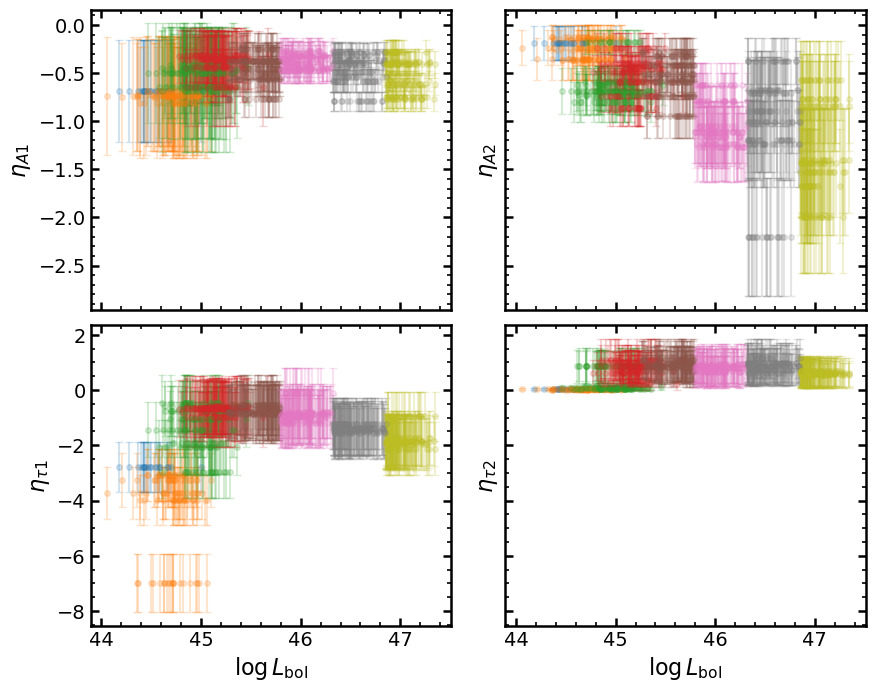

In [49]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex='col', sharey='row')
plt.subplots_adjust(hspace=0.05, wspace=0.15)

colors = plt.cm.tab10(np.linspace(0, 1, 9))

for lbolbin in [0] + list(range(1, 8)):
    df_agn = load_quasar_data(
        f"results/data/aug28_lbolbin_chisq_nobwb_qscpu_N20w4000s1000t8c4_lbolbinmerged/lbolbin{lbolbin}.h5",
        populate_sdss=False,
        apply_cut=False
    )
    print(f"+++++ Loaded {len(df_agn)} entries for LOGLBOL bin {lbolbin}\n\n")
    if df_agn.empty:
        continue

    axes[0, 0].errorbar(
        df_agn['LOGLBOL'], df_agn['eta_A1_mean'],
        yerr=df_agn['eta_A1_mean_err'],
        fmt='o', alpha=0.2, color=colors[lbolbin]
    )
    axes[0, 1].errorbar(
        df_agn['LOGLBOL'], df_agn['eta_A2_mean'],
        yerr=df_agn['eta_A2_mean_err'],
        fmt='o', alpha=0.2, color=colors[lbolbin]
    )
    axes[1, 0].errorbar(
        df_agn['LOGLBOL'], df_agn['eta_tau1_mean'],
        yerr=df_agn['eta_tau1_mean_err'],
        fmt='o', alpha=0.2, color=colors[lbolbin]
    )
    axes[1, 1].errorbar(
        df_agn['LOGLBOL'], df_agn['eta_tau2_mean'],
        yerr=df_agn['eta_tau2_mean_err'],
        fmt='o', alpha=0.2, color=colors[lbolbin]
    )

# Axis labels with Greek letters
axes[0, 0].set_ylabel(r'$\eta_{A1}$')
axes[0, 1].set_ylabel(r'$\eta_{A2}$')
axes[1, 0].set_ylabel(r'$\eta_{\tau1}$')
axes[1, 1].set_ylabel(r'$\eta_{\tau2}$')
for ax in axes[1, :]:
    ax.set_xlabel(r'$\log L_{\mathrm{bol}}$')

plt.savefig('plots/ancillary/eta_params_vs_LOGLBOL_lbolbins.png', dpi=300, bbox_inches='tight')
plt.show()


Reading quasars from HDF5: 100%|██████████| 20/20 [00:00<00:00, 194.71it/s]


Number of quasars loaded: 20
Number of quasars with 0 < z <= 1.0: 20
Number of quasars with z > 3: 0
Highest redshift quasar: 0.4152730338987721
Columns with NaNs: []
Skipping data cuts as apply_cut is False.
+++++ Loaded 20 entries for LOGLBOL bin 0




Reading quasars from HDF5: 100%|██████████| 160/160 [00:00<00:00, 236.41it/s]


Number of quasars loaded: 160
Number of quasars with 0 < z <= 1.0: 160
Number of quasars with z > 3: 0
Highest redshift quasar: 0.8204127074174955
Columns with NaNs: ['apparent_mag_g', 'apparent_mag_g_err', 'apparent_mag_i', 'apparent_mag_i_err', 'apparent_mag_r', 'apparent_mag_r_err', 'apparent_mag_u', 'apparent_mag_u_err', 'apparent_mag_z', 'apparent_mag_z_err']
Skipping data cuts as apply_cut is False.
+++++ Loaded 160 entries for LOGLBOL bin 2




Reading quasars from HDF5: 100%|██████████| 160/160 [00:00<00:00, 255.92it/s]


...

Number of quasars loaded: 160
Number of quasars with 0 < z <= 1.0: 10
Number of quasars with z > 3: 0
Highest redshift quasar: 2.75003476809475
Columns with NaNs: ['apparent_mag_g', 'apparent_mag_g_err', 'apparent_mag_i', 'apparent_mag_i_err', 'apparent_mag_r', 'apparent_mag_r_err', 'apparent_mag_u', 'apparent_mag_u_err', 'apparent_mag_z', 'apparent_mag_z_err', 'log_amp_delta_blr_u', 'log_amp_delta_blr_u_err', 'log_jitter_u', 'log_jitter_u_err', 'log_lag_blr_u', 'log_lag_blr_u_err', 'log_sigma_band_u', 'log_sigma_band_u_err', 'log_tau_band_u_RF', 'log_tau_band_u_RF_err', 'mean_u', 'mean_u_err', 'width_blr_u', 'width_blr_u_err', 'width_cont_u', 'width_cont_u_err', 'mags_mean_u']
Skipping data cuts as apply_cut is False.
+++++ Loaded 160 entries for LOGLBOL bin 5




Reading quasars from HDF5: 100%|██████████| 160/160 [00:00<00:00, 246.70it/s]


Number of quasars loaded: 160
Number of quasars with 0 < z <= 1.0: 7
Number of quasars with z > 3: 17
Highest redshift quasar: 3.833144515205685
Columns with NaNs: ['apparent_mag_g', 'apparent_mag_g_err', 'apparent_mag_i', 'apparent_mag_i_err', 'apparent_mag_r', 'apparent_mag_r_err', 'apparent_mag_u', 'apparent_mag_u_err', 'apparent_mag_z', 'apparent_mag_z_err', 'log_amp_delta_blr_g', 'log_amp_delta_blr_g_err', 'log_jitter_g', 'log_jitter_g_err', 'log_lag_blr_g', 'log_lag_blr_g_err', 'log_sigma_band_g', 'log_sigma_band_g_err', 'log_tau_band_g_RF', 'log_tau_band_g_RF_err', 'mean_g', 'mean_g_err', 'width_blr_g', 'width_blr_g_err', 'width_cont_g', 'width_cont_g_err', 'mags_mean_g', 'log_amp_delta_blr_u', 'log_amp_delta_blr_u_err', 'log_jitter_u', 'log_jitter_u_err', 'log_lag_blr_u', 'log_lag_blr_u_err', 'log_sigma_band_u', 'log_sigma_band_u_err', 'log_tau_band_u_RF', 'log_tau_band_u_RF_err', 'mean_u', 'mean_u_err', 'width_blr_u', 'width_blr_u_err', 'width_cont_u', 'width_cont_u_err', 'mag

Reading quasars from HDF5: 100%|██████████| 160/160 [00:00<00:00, 291.15it/s]


Number of quasars loaded: 160
Number of quasars with 0 < z <= 1.0: 0
Number of quasars with z > 3: 47
Highest redshift quasar: 4.085985216215788
Columns with NaNs: ['apparent_mag_u', 'log_amp_delta_blr_g', 'log_amp_delta_blr_g_err', 'log_jitter_g', 'log_jitter_g_err', 'log_lag_blr_g', 'log_lag_blr_g_err', 'log_sigma_band_g', 'log_sigma_band_g_err', 'log_tau_band_g_RF', 'log_tau_band_g_RF_err', 'mean_g', 'mean_g_err', 'width_blr_g', 'width_blr_g_err', 'width_cont_g', 'width_cont_g_err', 'mags_mean_g', 'log_amp_delta_blr_u', 'log_amp_delta_blr_u_err', 'log_jitter_u', 'log_jitter_u_err', 'log_lag_blr_u', 'log_lag_blr_u_err', 'log_sigma_band_u', 'log_sigma_band_u_err', 'log_tau_band_u_RF', 'log_tau_band_u_RF_err', 'mean_u', 'mean_u_err', 'width_blr_u', 'width_blr_u_err', 'width_cont_u', 'width_cont_u_err', 'mags_mean_u']
Skipping data cuts as apply_cut is False.
+++++ Loaded 160 entries for LOGLBOL bin 7




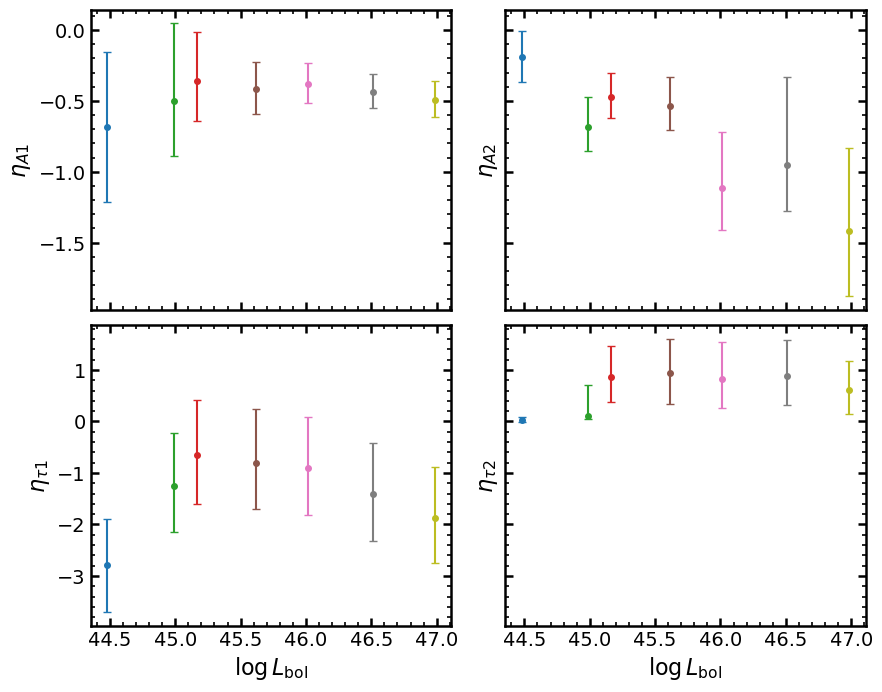

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex='col', sharey='row')
plt.subplots_adjust(hspace=0.05, wspace=0.15)

colors = plt.cm.tab10(np.linspace(0, 1, 9))

for lbolbin in [0] + list(range(2, 8)):
    df_agn = load_quasar_data(
        f"results/data/aug28_lbolbin_chisq_nobwb_qscpu_N20w4000s1000t8c4_lbolbinmerged/lbolbin{lbolbin}.h5",
        populate_sdss=False,
        apply_cut=False
    )
    print(f"+++++ Loaded {len(df_agn)} entries for LOGLBOL bin {lbolbin}\n\n")
    if df_agn.empty:
        continue

    median_lbol = np.median(df_agn['LOGLBOL'])

    def median_with_errorbar_from_err(column, err_column):
        median_val = np.median(df_agn[column])
        err_vals = df_agn[err_column]
        err_lower = np.percentile(err_vals, 16)
        err_upper = np.percentile(err_vals, 84)
        return median_val, [err_lower, err_upper]

    eta_A1, eta_A1_err = median_with_errorbar_from_err('eta_A1_mean', 'eta_A1_mean_err')
    eta_A2, eta_A2_err = median_with_errorbar_from_err('eta_A2_mean', 'eta_A2_mean_err')
    eta_tau1, eta_tau1_err = median_with_errorbar_from_err('eta_tau1_mean', 'eta_tau1_mean_err')
    eta_tau2, eta_tau2_err = median_with_errorbar_from_err('eta_tau2_mean', 'eta_tau2_mean_err')

    axes[0, 0].errorbar(median_lbol, eta_A1, yerr=np.array(eta_A1_err).reshape(2, 1), fmt='o', color=colors[lbolbin])
    axes[0, 1].errorbar(median_lbol, eta_A2, yerr=np.array(eta_A2_err).reshape(2, 1), fmt='o', color=colors[lbolbin])
    axes[1, 0].errorbar(median_lbol, eta_tau1, yerr=np.array(eta_tau1_err).reshape(2, 1), fmt='o', color=colors[lbolbin])
    axes[1, 1].errorbar(median_lbol, eta_tau2, yerr=np.array(eta_tau2_err).reshape(2, 1), fmt='o', color=colors[lbolbin])

# Axis labels with Greek letters
axes[0, 0].set_ylabel(r'$\eta_{A1}$')
axes[0, 1].set_ylabel(r'$\eta_{A2}$')
axes[1, 0].set_ylabel(r'$\eta_{\tau1}$')
axes[1, 1].set_ylabel(r'$\eta_{\tau2}$')
for ax in axes[1, :]:
    ax.set_xlabel(r'$\log L_{\mathrm{bol}}$')

plt.savefig('plots/ancillary/eta_params_vs_LOGLBOL_lbolbins.png', dpi=300, bbox_inches='tight')
plt.show()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Reading quasars from HDF5: 100%|██████████| 20/20 [00:00<00:00, 147.43it/s]

Number of quasars loaded: 20


Length of colin_df: 5136
Number with apparent_mag_2500 > 0: 4282
Length of merged DataFrame: 20
object_id not in merged: ['1417406', '1445329', '1450477', '1465964', '1419845', '1417358', '1411138', '1456049', '1409409', '1411647', '1453032']
Number of quasars with 0 < z <= 1.0: 20
Number of quasars with z > 3: 0
Highest redshift quasar: 0.4152730338987721
Columns with NaNs: ['f_host_4200', 'apparent_mag_2500', 'apparent_mag_2500_err', 'alpha_lambda', 'alpha_lambda_err', 'redchi']
Skipping data cuts as apply_cut is False.


Reading quasars from HDF5:   0%|          | 0/120 [00:00<?, ?it/s]

...

Number of quasars loaded: 120
Length of colin_df: 5136
Number with apparent_mag_2500 > 0: 4282
Length of merged DataFrame: 120
object_id not in merged: ['1425657', '1400958', '1401441', '1438589', '1412466', '1405646', '1416881', '1420903', '1450755', '1398610', '1446961', '1455721', '1385049', '1464048', '1411469', '1422527', '1450473', '1437643', '1398103', '1443693', '1394659', '1398789', '1419738', '1444489', '1431286', '1420577', '1450750', '1429839', '1422626', '1447825', '1429900', '1408680', '1464417', '1420038', '1432298', '1419767', '1418835', '1443064', '1423271', '1448355', '1442775', '1449213', '1402915', '1445155', '1459059', '1460640', '1417418', '1397117', '1414535', '1395401', '1416775', '1407615', '1447022', '1428620', '1459159', '1400867', '1420554', '1423781', '1446706', '1393528', '1458490', '1434518', '1412144', '1453324', '1398068', '1404315', '1433777', '1419861', '1405249']
Number of quasars with 0 < z <= 1.0: 9
Number of quasars with z > 3: 0
Highest redshift 

Reading quasars from HDF5: 100%|██████████| 60/60 [00:00<00:00, 146.13it/s]


Number of quasars loaded: 60
Length of colin_df: 5136
Number with apparent_mag_2500 > 0: 4282
Length of merged DataFrame: 60
object_id not in merged: ['1441521', '1438668', '1465528', '1407747', '1422027', '1418269', '1428168', '1435949', '1465875', '1441864', '1430599', '1452992', '1445535', '1435845', '1451309', '1402316', '1419450', '1388826', '1414701', '1463940', '1425039', '1409774', '1448806', '1392568', '1414556', '1451234', '1456132', '1427605', '1449617', '1397854', '1452600', '1417592', '1457231', '1435708', '1448300', '1419699', '1453014', '1428312', '1466252', '1445899', '1463301', '1415529', '1451416', '1424948', '1421843', '1397529']
Number of quasars with 0 < z <= 1.0: 3
Number of quasars with z > 3: 7
Highest redshift quasar: 3.3401701353786217
Columns with NaNs: ['apparent_mag_g', 'apparent_mag_g_err', 'apparent_mag_i', 'apparent_mag_i_err', 'apparent_mag_r', 'apparent_mag_r_err', 'apparent_mag_u', 'apparent_mag_u_err', 'apparent_mag_z', 'apparent_mag_z_err', 'f_host_

Reading quasars from HDF5: 100%|██████████| 80/80 [00:00<00:00, 154.30it/s]


Number of quasars loaded: 80
Length of colin_df: 5136
Number with apparent_mag_2500 > 0: 4282
Length of merged DataFrame: 80
object_id not in merged: ['1459904', '1402384', '1421139', '1447046', '1451575', '1411772', '1394536', '1440305', '1401888', '1438297', '1444406', '1413803', '1440068', '1427907', '1450579', '1410004', '1448626', '1448820', '1452051', '1431969', '1444926', '1396488', '1446583', '1415296', '1395580', '1413760', '1413928', '1466681', '1392470', '1441338', '1444856', '1397233', '1407339', '1432339', '1461084', '1401756', '1458719', '1444836', '1402228', '1465417', '1444982', '1441383', '1433974', '1459849', '1450006', '1451353', '1420306', '1437555', '1442699']
Number of quasars with 0 < z <= 1.0: 0
Number of quasars with z > 3: 22
Highest redshift quasar: 3.9210370051341137
Columns with NaNs: ['apparent_mag_u', 'f_host_4200', 'apparent_mag_2500', 'apparent_mag_2500_err', 'alpha_lambda', 'alpha_lambda_err', 'redchi']
Skipping data cuts as apply_cut is False.


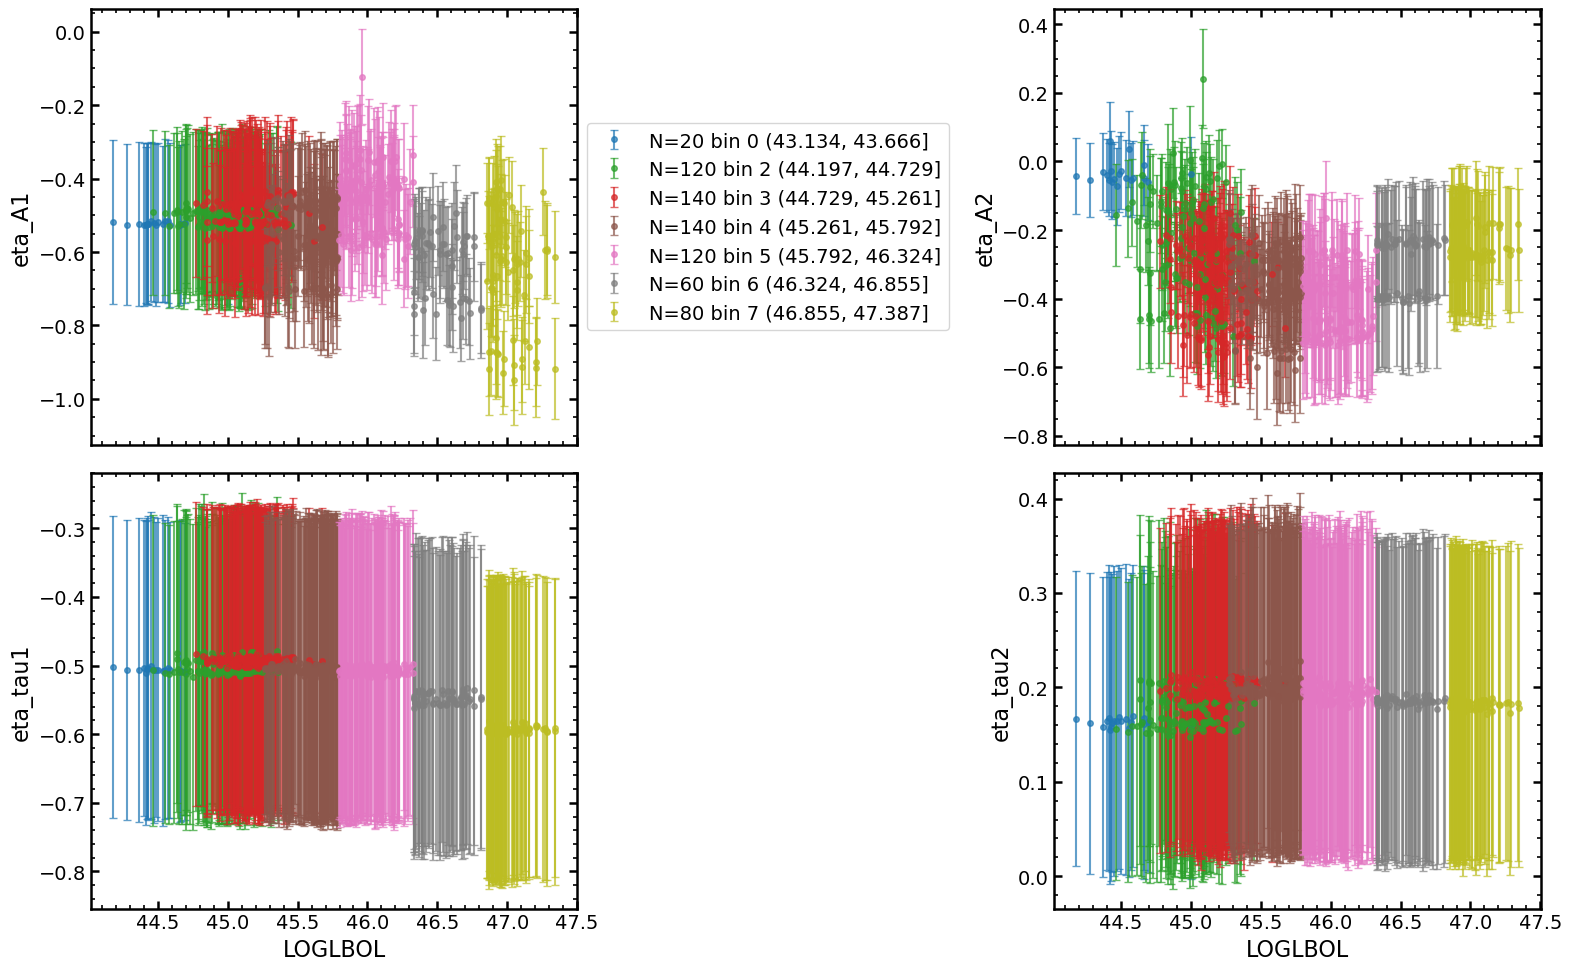

In [15]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

#from tqdm import tqdm

from hubble_utils import *
import matplotlib.pyplot as plt
plt.style.use('style.mplstyle')
import pandas as pd
import numpy as np

bin_info = [
    "bin 0 (43.134, 43.666]",
    "bin 1 (43.666, 44.197]",
    "bin 2 (44.197, 44.729]",
    "bin 3 (44.729, 45.261]",
    "bin 4 (45.261, 45.792]",
    "bin 5 (45.792, 46.324]",
    "bin 6 (46.324, 46.855]",
    "bin 7 (46.855, 47.387]",
    "bin 8 (47.387, 47.919]"
]


fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex='col')

colors = plt.cm.tab10(np.linspace(0, 1, 9))
for lbolbin in [0] + list(range(2, 8)):
    df_agn = load_quasar_data(
        f"results/data/aug17/aug17_lbolbin_chisq_nobwb_qscpu_N20w4000s1000t8c4_lbolbinmerged/lbolbin{lbolbin}.h5",
        populate_sdss=False,
        apply_cut=False
    )
    # Top row: eta_A1, eta_A2
    axes[0, 0].errorbar(
        df_agn['LOGLBOL'], df_agn['eta_A1'],
        yerr=df_agn['eta_A1_err'],
        fmt='o', alpha=0.7, color=colors[lbolbin], label=f"N={len(df_agn)} {bin_info[lbolbin]}"
    )
    axes[0, 1].errorbar(
        df_agn['LOGLBOL'], df_agn['eta_A2'],
        yerr=df_agn['eta_A2_err'],
        fmt='o', alpha=0.7, color=colors[lbolbin]
    )
    # Bottom row: eta_tau1, eta_tau2
    axes[1, 0].errorbar(
        df_agn['LOGLBOL'], df_agn['eta_tau1'],
        yerr=df_agn['eta_tau1_err'],
        fmt='o', alpha=0.7, color=colors[lbolbin]
    )
    axes[1, 1].errorbar(
        df_agn['LOGLBOL'], df_agn['eta_tau2'],
        yerr=df_agn['eta_tau2_err'],
        fmt='o', alpha=0.7, color=colors[lbolbin]
    )

axes[0, 0].set_ylabel('eta_A1')
axes[0, 1].set_ylabel('eta_A2')
axes[1, 0].set_ylabel('eta_tau1')
axes[1, 1].set_ylabel('eta_tau2')
for ax in axes[1, :]:
    ax.set_xlabel('LOGLBOL')
axes[0, 0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
    
plt.tight_layout()
plt.show()